In [1]:
import ray
import time
import numpy as np

if ray.is_initialized():
    ray.shutdown()

ray.init(num_cpus=8,
         ignore_reinit_error=True,
         logging_level="WARNING",
         include_dashboard=True)


Python version:,3.10.12
Ray version:,2.44.1
Dashboard:,http://127.0.0.1:8265


In [2]:
def get_ray_connection_ssh_cmd():
    user_name = "epak"
    hostname = !hostname
    hostname = hostname[0]
    print(f"ssh -J {user_name}@login.expanse.sdsc.edu -L 8265:localhost:8265 {user_name}@{hostname}.expanse.sdsc.edu")
get_ray_connection_ssh_cmd()

ssh -J epak@login.expanse.sdsc.edu -L 8265:localhost:8265 epak@exp-3-14.expanse.sdsc.edu


In [45]:
ds = ray.data.read_parquet("/expanse/lustre/scratch/epak/temp_project/stead_version4")

Metadata Fetch Progress 0:   0%|          | 0.00/140 [00:00<?, ? task/s]

Parquet Files Sample 0:   0%|          | 0.00/8.00 [00:00<?, ? file/s]

In [46]:
# 1. Include your metadata columns right from the start
ds = ds.select_columns([
    "waveform_N", 
    "waveform_Z", 
    "waveform_E", 
    "trace_category", 
    "p_arrival_sample", 
    "s_arrival_sample"
])

def filter_earthquake(batch):
    mask = batch["trace_category"] == "earthquake_local"
    return batch[mask]

# Run the vectorized filter
eq_ds = ds.map_batches(filter_earthquake, batch_format="pandas")

eq_ds = eq_ds.drop_columns(["trace_category"])

def svd_polarization_filter(n_channel, z_channel, e_channel, k=1):

    M = np.column_stack([n_channel, z_channel, e_channel])
    U, S, Vt = np.linalg.svd(M, full_matrices=False)
    M_denoised = (U[:, :k] * S[:k]) @ Vt[:k, :]
    return M_denoised[:, 0], M_denoised[:, 1], M_denoised[:, 2]

def denoise_batch(batch):

    denoised_N, denoised_Z, denoised_E = [], [], []
    
    for n, z, e in zip(batch["waveform_N"], batch["waveform_Z"], batch["waveform_E"]):
        clean_n, clean_z, clean_e = svd_polarization_filter(n, z, e, k=1)
        denoised_N.append(clean_n)
        denoised_Z.append(clean_z)
        denoised_E.append(clean_e)
        
    batch["denoised_waveform_N"] = denoised_N
    batch["denoised_waveform_Z"] = denoised_Z
    batch["denoised_waveform_E"] = denoised_E
    
    return batch

# Run the SVD filter directly on eq_ds
denoised_ds = eq_ds.map_batches(denoise_batch, batch_format="pandas")

In [49]:
# Write denoised waveform data to parquet file
import os
output_dir = os.environ.get('HOME')+"/epak/denoised_waveforms_parquets"

print(f"Executing SVD pipeline and writing to {output_dir}...")

# This is an ACTION. It wakes up the cluster, runs the SVD filter 
# on the dataset and saves the results directly to disk.
denoised_ds.write_parquet(output_dir)

print("Write complete!")

2026-05-28 22:51:46,628	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/ray/session_2026-05-28_20-36-25_220658_3665340/logs/ray-data
2026-05-28 22:51:46,628	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet->Project->MapBatches(filter_earthquake)->MapBatches(drop_columns)->MapBatches(denoise_batch)->Write]


Executing SVD pipeline and writing to /home/epak/epak/denoised_waveforms_parquets...


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquet->Project->MapBatches(filter_earthquake)->MapBatches(drop_columns)->...->Write 1: 0.00 row [00:00…

(ReadParquet->Project->MapBatches(filter_earthquake)->MapBatches(drop_columns)->MapBatches(denoise_batch)->Write pid=3699018) Error calculating size for column 'waveform_N': cannot call `vectorize` on size 0 inputs unless `otypes` is set
(ReadParquet->Project->MapBatches(filter_earthquake)->MapBatches(drop_columns)->MapBatches(denoise_batch)->Write pid=3699018) Error calculating size for column 'waveform_Z': cannot call `vectorize` on size 0 inputs unless `otypes` is set
(ReadParquet->Project->MapBatches(filter_earthquake)->MapBatches(drop_columns)->MapBatches(denoise_batch)->Write pid=3699018) Error calculating size for column 'waveform_E': cannot call `vectorize` on size 0 inputs unless `otypes` is set
(ReadParquet->Project->MapBatches(filter_earthquake)->MapBatches(drop_columns)->MapBatches(denoise_batch)->Write pid=3699018) Error calculating size for column 'trace_category': cannot call `vectorize` on size 0 inputs unless `otypes` is set
(ReadParquet->Project->MapBatches(filter_ear

Write complete!


## Visualization of Waveform Before and After Polarization Filtering / Denoising (SVD)

2026-05-28 22:50:29,013	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/ray/session_2026-05-28_20-36-25_220658_3665340/logs/ray-data
2026-05-28 22:50:29,013	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet->Project->MapBatches(filter_earthquake)->MapBatches(drop_columns)->MapBatches(denoise_batch)] -> LimitOperator[limit=1]


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquet->Project->MapBatches(filter_earthquake)->...->MapBatches(denoise_batch) 1: 0.00 row [00:00, ? ro…

- limit=1 2: 0.00 row [00:00, ? row/s]

(ReadParquet->Project->MapBatches(filter_earthquake)->MapBatches(drop_columns)->MapBatches(denoise_batch) pid=3699016) Error calculating size for column 'waveform_N': cannot call `vectorize` on size 0 inputs unless `otypes` is set
(ReadParquet->Project->MapBatches(filter_earthquake)->MapBatches(drop_columns)->MapBatches(denoise_batch) pid=3699016) Error calculating size for column 'waveform_Z': cannot call `vectorize` on size 0 inputs unless `otypes` is set
(ReadParquet->Project->MapBatches(filter_earthquake)->MapBatches(drop_columns)->MapBatches(denoise_batch) pid=3699016) Error calculating size for column 'waveform_E': cannot call `vectorize` on size 0 inputs unless `otypes` is set
(ReadParquet->Project->MapBatches(filter_earthquake)->MapBatches(drop_columns)->MapBatches(denoise_batch) pid=3699016) Error calculating size for column 'trace_category': cannot call `vectorize` on size 0 inputs unless `otypes` is set
(ReadParquet->Project->MapBatches(filter_earthquake)->MapBatches(drop_co

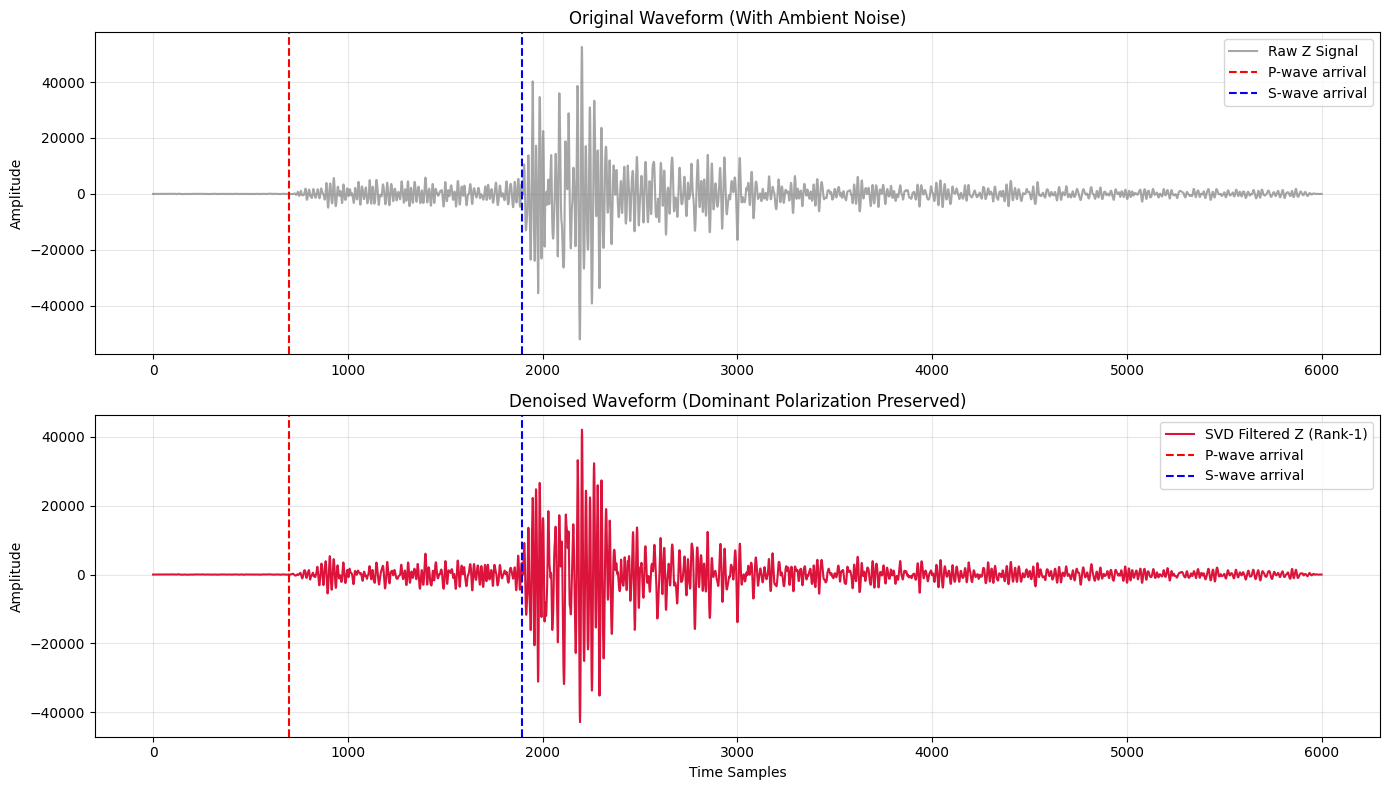

In [47]:
import matplotlib.pyplot as plt

# Pull a single example row from the cluster
sample_event = denoised_ds.take(1)[0]

time_axis = np.arange(6000)

plt.figure(figsize=(14, 8))

# Plot Vertical (Z) Component Before vs After
plt.subplot(2, 1, 1)
plt.plot(time_axis, sample_event["waveform_Z"], color='gray', alpha=0.7, label='Raw Z Signal')
plt.axvline(x=float(sample_event['p_arrival_sample']), color='red', linestyle='--', label='P-wave arrival')
plt.axvline(x=float(sample_event['s_arrival_sample']), color='blue', linestyle='--', label='S-wave arrival') 
plt.title("Original Waveform (With Ambient Noise)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(time_axis, sample_event["denoised_waveform_Z"], color='crimson', label='SVD Filtered Z (Rank-1)')
plt.axvline(x=float(sample_event['p_arrival_sample']), color='red', linestyle='--', label='P-wave arrival')
plt.axvline(x=float(sample_event['s_arrival_sample']), color='blue', linestyle='--', label='S-wave arrival')
plt.title("Denoised Waveform (Dominant Polarization Preserved)")
plt.xlabel("Time Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

As you can see, we see some amplitude after the arrival of the earthquake's first wave. However, the amplitude is significantly larger resulting from the arrival of the earthquake's second wave. This confirms the commonly held notion that the second waves of earthquakes are the danger.

In [48]:
sample_event

{'waveform_N': array([-0.        , -0.03259867, -0.07897092, ..., -0.12264204,
        -0.05204263, -0.        ], shape=(6000,), dtype=float32),
 'waveform_Z': array([-0.        , -0.0085106 , -0.02285321, ...,  0.10581018,
         0.00339233, -0.        ], shape=(6000,), dtype=float32),
 'waveform_E': array([ 0.        ,  0.00775105,  0.02457174, ..., -0.062743  ,
        -0.01183952, -0.        ], shape=(6000,), dtype=float32),
 'p_arrival_sample': '700.0',
 's_arrival_sample': '1894.0',
 'denoised_waveform_N': array([-1.2534281e-11, -1.4163726e-02, -3.5363201e-02, ...,
         1.0847517e-02, -1.4678868e-02,  0.0000000e+00],
       shape=(6000,), dtype=float32),
 'denoised_waveform_Z': array([-1.8576068e-11, -2.0990940e-02, -5.2409008e-02, ...,
         1.6076248e-02, -2.1754391e-02,  0.0000000e+00],
       shape=(6000,), dtype=float32),
 'denoised_waveform_E': array([ 1.00422505e-13,  1.13477341e-04,  2.83323898e-04, ...,
        -8.69084397e-05,  1.17604570e-04,  0.00000000e+00],

## Visualization of how SVD projects our 3D seismic data onto a 1D line

2026-05-28 22:30:43,362	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/ray/session_2026-05-28_20-36-25_220658_3665340/logs/ray-data
2026-05-28 22:30:43,362	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet->Project->MapBatches(filter_earthquake)->MapBatches(denoise_batch)] -> LimitOperator[limit=1]


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquet->Project->MapBatches(filter_earthquake)->MapBatches(denoise_batch) 1: 0.00 row [00:00, ? row/s]

- limit=1 2: 0.00 row [00:00, ? row/s]

(ReadParquet->Project->MapBatches(filter_earthquake)->MapBatches(denoise_batch) pid=3670319) Error calculating size for column 'waveform_N': cannot call `vectorize` on size 0 inputs unless `otypes` is set
(ReadParquet->Project->MapBatches(filter_earthquake)->MapBatches(denoise_batch) pid=3670319) Error calculating size for column 'waveform_Z': cannot call `vectorize` on size 0 inputs unless `otypes` is set
(ReadParquet->Project->MapBatches(filter_earthquake)->MapBatches(denoise_batch) pid=3670319) Error calculating size for column 'waveform_E': cannot call `vectorize` on size 0 inputs unless `otypes` is set
(ReadParquet->Project->MapBatches(filter_earthquake)->MapBatches(denoise_batch) pid=3670319) Error calculating size for column 'trace_category': cannot call `vectorize` on size 0 inputs unless `otypes` is set
(ReadParquet->Project->MapBatches(filter_earthquake)->MapBatches(denoise_batch) pid=3670319) Error calculating size for column 'p_arrival_sample': cannot call `vectorize` on si

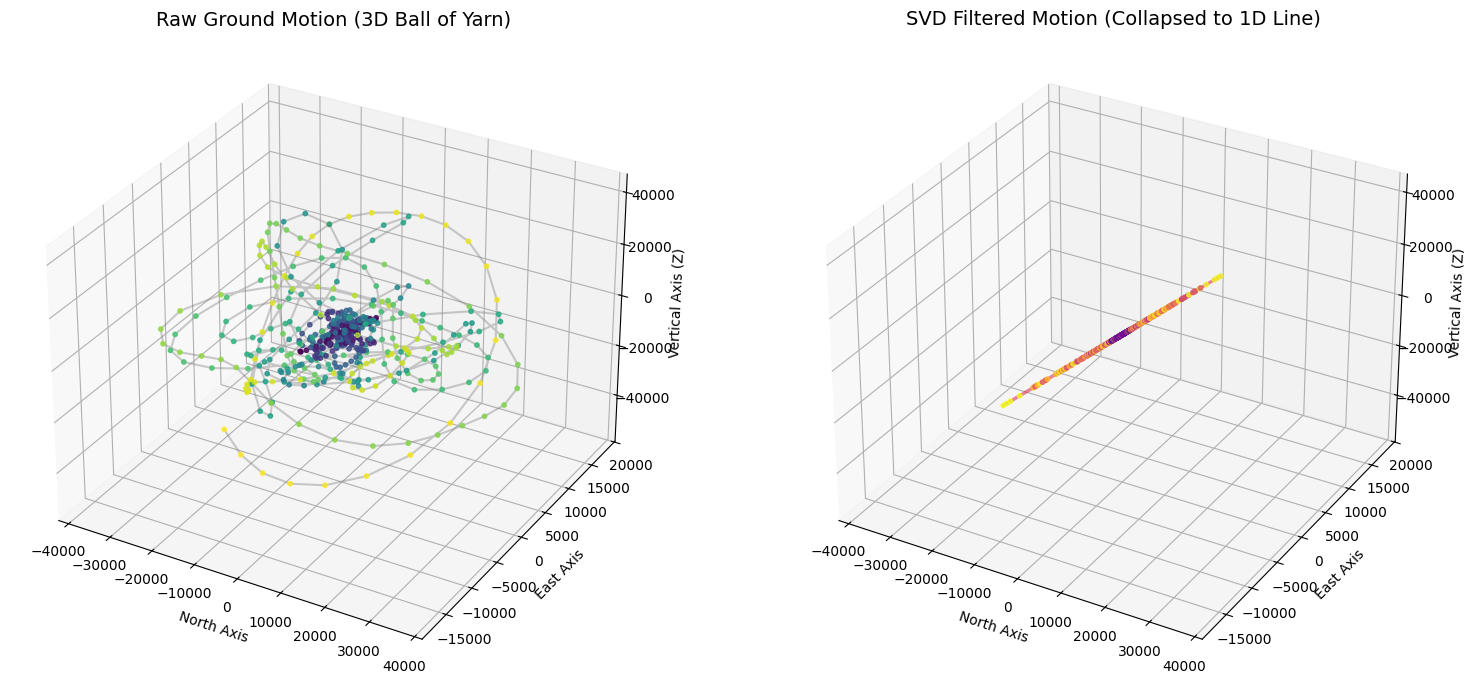

In [44]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 1. Grab a single event from the Ray dataset
sample_event = denoised_ds.take(1)[0]

# 2. Focus on a window where the wave might arrives (this code captures samples 1000 to 1500 out of all 6000 samples)
# Arbitrary window of time, may not necessarily capture the s-wave arrival time
start_idx = int(float(sample_event['s_arrival_sample']))-200
end_idx = int(float(sample_event['s_arrival_sample']))+300

# Extract Raw Data Window
raw_n = np.array(sample_event["waveform_N"])[start_idx:end_idx]
raw_z = np.array(sample_event["waveform_Z"])[start_idx:end_idx]
raw_e = np.array(sample_event["waveform_E"])[start_idx:end_idx]

# Extract Denoised Data Window
clean_n = np.array(sample_event["denoised_waveform_N"])[start_idx:end_idx]
clean_z = np.array(sample_event["denoised_waveform_Z"])[start_idx:end_idx]
clean_e = np.array(sample_event["denoised_waveform_E"])[start_idx:end_idx]

# 3. Setup the 3D Plotting Environment
fig = plt.figure(figsize=(16, 7))

# --- Plot 1: Raw 3D Ground Motion ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
# We use a colormap (viridis) to show the progression of time
time_colors = np.linspace(0, 1, len(raw_n))
sc1 = ax1.scatter(raw_n, raw_e, raw_z, c=time_colors, cmap='viridis', s=10, alpha=0.8)
ax1.plot(raw_n, raw_e, raw_z, color='gray', alpha=0.4) # Connecting line

ax1.set_title("Raw Ground Motion (3D Ball of Yarn)", fontsize=14)
ax1.set_xlabel("North Axis")
ax1.set_ylabel("East Axis")
ax1.set_zlabel("Vertical Axis (Z)")
ax1.grid(True, alpha=0.3)

# --- Plot 2: SVD Filtered 1D Ground Motion ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(clean_n, clean_e, clean_z, c=time_colors, cmap='plasma', s=10, alpha=0.8)
ax2.plot(clean_n, clean_e, clean_z, color='crimson', alpha=0.5, linewidth=2) # Connecting line

ax2.set_title("SVD Filtered Motion (Collapsed to 1D Line)", fontsize=14)
ax2.set_xlabel("North Axis")
ax2.set_ylabel("East Axis")
ax2.set_zlabel("Vertical Axis (Z)")
ax2.grid(True, alpha=0.3)

# Match the axis limits of the second plot to the first one for fair comparison
ax2.set_xlim(ax1.get_xlim())
ax2.set_ylim(ax1.get_ylim())
ax2.set_zlim(ax1.get_zlim())

plt.tight_layout()
plt.show()

### Color Interpretation

#### Left Plot
Dark Purple / Dark Blue: This is the start of the plot's time window (start_idx). This is the ground motion right before the main S-wave energy hits.

Teal / Green: The middle of the time window. This is approximately the peak of the S-wave arrival.

Bright Yellow: The very end of your time window (end_idx). This is the lingering motion as the wave passes.

#### Right Plot
Dark Purple: Right before the main S-wave energy hits.

Vibrant Pink / Orange: The middle of the window (the S-wave arrival).

Bright Yellow: The end of the window; the lingering motion as the wave passes.